# Market Crash Prediction — CatBoost / LightGBM / XGBoost / Random Forest (calibrated, same scale)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import phik
from matplotlib import pyplot as plt
import seaborn as sns

import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb


/opt/miniconda3/envs/xgb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

In [2]:
start_date = '2010-01-01'
end_date = '2026-06-18'

data = yf.download("^NSEI", start_date, end_date)
vix   = yf.download("^INDIAVIX", start_date, end_date)
gold  = yf.download("GC=F", start_date, end_date)
crude = yf.download("CL=F", start_date, end_date)
usdinr = yf.download("INR=X", start_date, end_date)

data['Vix'] = vix['Close']
data['Gold'] = gold['Close']
data['Crude'] = crude['Close']
data['Usdinr'] = usdinr['Close']

data.drop('Volume', axis=1, inplace=True)
data.columns = data.columns.droplevel('Ticker')
data = data.sort_index()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Vix,Gold,Crude,Usdinr
Date,,,,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,23.639999,1117.699951,81.510002,46.287998
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,22.270000,1118.099976,81.769997,46.119999
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,22.120001,1135.900024,83.180000,45.720001
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,22.500000,1133.099976,82.660004,45.688000
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,22.570000,1138.199951,82.750000,45.518002


## 2. Feature engineering

In [4]:
def create_features(df):
    df = df.copy()
    df["vix_ret_5"] = df["Vix"].ffill().pct_change(5)
    df["vix_ret_21"] = df["Vix"].ffill().pct_change(21)

    df["gold_ret_21"] = df["Gold"].ffill().pct_change(21)

    df["crude_ret_21"] = df["Crude"].ffill().pct_change(21)

    df["usdinr_ret_21"] = df["Usdinr"].ffill().pct_change(21)

    df["ret_1"] = df["Close"].pct_change(1)
    df["ret_5"] = df["Close"].pct_change(5)
    df["ret_21"] = df["Close"].pct_change(21)
    df["ret_63"] = df["Close"].pct_change(63)

    df["vol_21"] = df["ret_1"].rolling(21).std()
    df["vol_63"] = df["ret_1"].rolling(63).std()

    rolling_max_21 = df["Close"].rolling(21).max()
    df["drawdown_21"] = (df["Close"] / rolling_max_21 - 1)
    rolling_max_63 = df["Close"].rolling(63).max()
    df["drawdown_63"] = (df["Close"] / rolling_max_63 - 1)
    rolling_max_252 = df["Close"].rolling(252).max()
    df["drawdown_252"] = (df["Close"] / rolling_max_252 - 1)

    df["ema50"] = df["Close"].ewm(span=50).mean()
    df["ema200"] = df["Close"].ewm(span=200).mean()

    df["ema50_dist"] = (df["Close"] / df["ema50"] - 1)

    df["ema200_dist"] = (df["Close"] / df["ema200"] - 1)

    high_low = df["High"] - df["Low"]
    high_close = abs(df["High"] - df["Close"].shift())
    low_close = abs(df["Low"] - df["Close"].shift())

    tr = pd.concat(
    [high_low, high_close, low_close],
    axis=1).max(axis=1)

    df["atr_14"] = tr.rolling(14).mean()

    df["atr_pct"] = df["atr_14"] / df["Close"]

    # Compute future_dd first
    future_min = pd.Series(
    [df["Low"].iloc[i+1:i+22].min()
     if i+21 < len(df)
     else np.nan
     for i in range(len(df))],
    index=df.index)

    future_dd = future_min / df["Close"] - 1

    df["crash"] = (future_dd < -0.08)
    df["crash"] = df["crash"].astype('int64')

    return df


In [5]:
data_features = create_features(data)

In [6]:
data_features.tail()

Price,Close,High,Low,Open,Vix,Gold,Crude,Usdinr,vix_ret_5,vix_ret_21,...,drawdown_21,drawdown_63,drawdown_252,ema50,ema200,ema50_dist,ema200_dist,atr_14,atr_pct,crash
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-11,23161.599609,23327.449219,23072.050781,23104.400391,15.61,4090.300049,87.709999,95.644501,-0.017621,-0.190353,...,-0.036206,-0.057575,-0.120286,23776.243865,24490.101888,-0.025851,-0.054246,272.742746,0.011776,0
2026-06-12,23622.900391,23645.349609,23313.900391,23412.550781,14.72,4215.000000,84.879997,95.760101,-0.067764,-0.242409,...,-0.017011,-0.038805,-0.102765,23770.230396,24481.473017,-0.006198,-0.035070,294.371233,0.012461,0
2026-06-15,23853.900391,24011.400391,23817.800781,23984.849609,14.35,4328.000000,80.750000,95.110298,-0.157369,-0.228909,...,-0.007399,-0.029406,-0.093991,23773.511572,24475.228513,0.003381,-0.025386,298.182059,0.012500,0
2026-06-16,23989.150391,24002.599609,23888.199219,23923.900391,13.36,4330.899902,76.050003,94.741699,-0.142490,-0.288984,...,-0.001771,-0.023903,-0.088854,23781.967996,24470.391915,0.008712,-0.019666,294.206892,0.012264,0
2026-06-17,24085.699219,24108.199219,23969.699219,24044.500000,13.19,4358.899902,76.790001,94.888603,-0.156110,-0.328069,...,0.000000,-0.019974,-0.085187,23793.879024,24466.564127,0.012265,-0.015567,295.174805,0.012255,0


## 3. Train / prediction split

In [7]:
train_data = data_features.iloc[252:-21, :]
pred_data = data_features.iloc[-21:, :-1]


In [8]:
train_data.tail()

Price,Close,High,Low,Open,Vix,Gold,Crude,Usdinr,vix_ret_5,vix_ret_21,...,drawdown_21,drawdown_63,drawdown_252,ema50,ema200,ema50_dist,ema200_dist,atr_14,atr_pct,crash
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-12,23379.550781,23757.550781,23348.400391,23722.599609,19.280001,4677.600098,102.180000,95.391403,0.076494,-0.056290,...,-0.048707,-0.099188,-0.112008,24146.633890,24715.442453,-0.031768,-0.054051,297.696150,0.012733,0
2026-05-13,23412.599609,23582.949219,23262.550781,23362.449219,19.430000,4697.700195,101.019997,95.633003,0.164868,0.030769,...,-0.047362,-0.097914,-0.110752,24117.848232,24702.478842,-0.029242,-0.052217,304.603237,0.013010,0
2026-05-14,23689.599609,23777.199219,23426.550781,23530.250000,18.610001,4678.100098,101.169998,95.695801,0.119735,-0.092195,...,-0.036091,-0.087241,-0.100232,24101.054168,24692.400442,-0.017072,-0.040612,313.267578,0.013224,0
2026-05-15,23643.500000,23839.300781,23610.300781,23731.400391,18.790001,4555.799805,105.419998,95.709900,0.115796,0.006427,...,-0.037967,-0.089018,-0.101982,24083.110867,24681.963622,-0.018254,-0.042074,301.599749,0.012756,0
2026-05-18,23649.949219,23695.650391,23317.099609,23482.199219,19.629999,4552.500000,108.660004,95.970299,0.058221,0.085130,...,-0.037705,-0.088769,-0.101738,24066.124136,24671.694822,-0.017293,-0.041414,312.014090,0.013193,0


In [9]:
pred_data.tail()

Price,Close,High,Low,Open,Vix,Gold,Crude,Usdinr,vix_ret_5,vix_ret_21,...,vol_63,drawdown_21,drawdown_63,drawdown_252,ema50,ema200,ema50_dist,ema200_dist,atr_14,atr_pct
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-11,23161.599609,23327.449219,23072.050781,23104.400391,15.61,4090.300049,87.709999,95.644501,-0.017621,-0.190353,...,0.012206,-0.036206,-0.057575,-0.120286,23776.243865,24490.101888,-0.025851,-0.054246,272.742746,0.011776
2026-06-12,23622.900391,23645.349609,23313.900391,23412.550781,14.72,4215.000000,84.879997,95.760101,-0.067764,-0.242409,...,0.012294,-0.017011,-0.038805,-0.102765,23770.230396,24481.473017,-0.006198,-0.035070,294.371233,0.012461
2026-06-15,23853.900391,24011.400391,23817.800781,23984.849609,14.35,4328.000000,80.750000,95.110298,-0.157369,-0.228909,...,0.012295,-0.007399,-0.029406,-0.093991,23773.511572,24475.228513,0.003381,-0.025386,298.182059,0.012500
2026-06-16,23989.150391,24002.599609,23888.199219,23923.900391,13.36,4330.899902,76.050003,94.741699,-0.142490,-0.288984,...,0.012142,-0.001771,-0.023903,-0.088854,23781.967996,24470.391915,0.008712,-0.019666,294.206892,0.012264
2026-06-17,24085.699219,24108.199219,23969.699219,24044.500000,13.19,4358.899902,76.790001,94.888603,-0.156110,-0.328069,...,0.012088,0.000000,-0.019974,-0.085187,23793.879024,24466.564127,0.012265,-0.015567,295.174805,0.012255


In [10]:
train_data['crash'].value_counts(normalize=True)

crash
0    0.924608
1    0.075392
Name: proportion, dtype: float64

In [11]:
train_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Vix', 'Gold', 'Crude', 'Usdinr',
       'vix_ret_5', 'vix_ret_21', 'gold_ret_21', 'crude_ret_21',
       'usdinr_ret_21', 'ret_1', 'ret_5', 'ret_21', 'ret_63', 'vol_21',
       'vol_63', 'drawdown_21', 'drawdown_63', 'drawdown_252', 'ema50',
       'ema200', 'ema50_dist', 'ema200_dist', 'atr_14', 'atr_pct', 'crash'],
      dtype='object', name='Price')

In [12]:
train_data.shape

(3767, 29)

In [13]:
'''corr = train_data.phik_matrix()        # magnitude
sig  = train_data.significance_matrix() # Z-scores

threshold = 3.0  # roughly p < 0.001 (two-tailed)
trusted_corr = corr[sig > threshold]'''

'corr = train_data.phik_matrix()        # magnitude\nsig  = train_data.significance_matrix() # Z-scores\n\nthreshold = 3.0  # roughly p < 0.001 (two-tailed)\ntrusted_corr = corr[sig > threshold]'

In [14]:
#plt.figure(figsize = (20,20))
#sns.heatmap(trusted_corr)

## 4. Shared features/target

In [15]:
X = train_data.drop(columns=['crash'])
y = train_data['crash']

# Used by XGBoost's imbalance handling (its equivalent of CatBoost's
# auto_class_weights / LightGBM's is_unbalance): ratio of majority to
# minority class, fed to scale_pos_weight.
scale_pos_weight_value = (y == 0).sum() / (y == 1).sum()
print("scale_pos_weight:", scale_pos_weight_value)


scale_pos_weight: 12.264084507042254


## 5. CatBoost — hyperparameter tuning (Optuna)

In [16]:
def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 254),
        'auto_class_weights': 'Balanced', # Crucial for the ~8% minority 'crash' class
        'random_seed': 42,
        'verbose': 0
    }

    tscv = TimeSeriesSplit(n_splits=3, gap=21)
    scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0
        )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("Starting Optuna Optimization (CatBoost)...")
study_cb = optuna.create_study(direction='maximize', study_name='catboost_crash_tuning')
study_cb.optimize(objective_cb, n_trials=100)

best_params_cb = study_cb.best_params
best_params_cb['auto_class_weights'] = 'Balanced'
best_params_cb['random_seed'] = 42
best_params_cb['verbose'] = 0

print(f"\nBest ROC-AUC (CatBoost): {study_cb.best_value:.4f}")
print(f"Best Hyperparameters (CatBoost): {best_params_cb}")


[I 2026-06-19 21:05:19,414] A new study created in memory with name: catboost_crash_tuning


Starting Optuna Optimization (CatBoost)...


[I 2026-06-19 21:05:38,145] Trial 0 finished with value: 0.6209219473677265 and parameters: {'iterations': 800, 'depth': 10, 'learning_rate': 0.010240192508825274, 'l2_leaf_reg': 0.3355503569655677, 'bagging_temperature': 3.5672109820975075, 'border_count': 195}. Best is trial 0 with value: 0.6209219473677265.
[I 2026-06-19 21:05:42,988] Trial 1 finished with value: 0.6424561407021151 and parameters: {'iterations': 949, 'depth': 7, 'learning_rate': 0.016852471972520034, 'l2_leaf_reg': 2.2096553258460805, 'bagging_temperature': 1.690182738967686, 'border_count': 98}. Best is trial 1 with value: 0.6424561407021151.
[I 2026-06-19 21:05:54,086] Trial 2 finished with value: 0.5959717827997036 and parameters: {'iterations': 818, 'depth': 9, 'learning_rate': 0.015769409150806026, 'l2_leaf_reg': 0.5792804754630764, 'bagging_temperature': 2.163557598843704, 'border_count': 159}. Best is trial 1 with value: 0.6424561407021151.
[I 2026-06-19 21:05:55,530] Trial 3 finished with value: 0.6233002250


Best ROC-AUC (CatBoost): 0.7225
Best Hyperparameters (CatBoost): {'iterations': 915, 'depth': 4, 'learning_rate': 0.011087474024424357, 'l2_leaf_reg': 0.19500328134451508, 'bagging_temperature': 7.082518856813896, 'border_count': 80, 'auto_class_weights': 'Balanced', 'random_seed': 42, 'verbose': 0}


## 6. CatBoost — calibration

`auto_class_weights='Balanced'` reweights classes during training so the model can learn the rare "crash" pattern. The side effect: `predict_proba` no longer returns a real-world probability — it returns a score calibrated to the artificially rebalanced classes, and each library distorts this differently internally. That's why raw outputs across models aren't comparable to each other or to the true ~8% base rate.

Fix: calibrate the tuned model post-hoc with Platt scaling (sigmoid), using the same `TimeSeriesSplit(gap=21)` used during tuning (so no look-ahead leakage from the 21-day-forward label). This maps raw scores back to actual P(crash), putting every model's output on the same 0–100% scale.

In [17]:
calibrated_model_cb = CalibratedClassifierCV(
    estimator=CatBoostClassifier(**best_params_cb),
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5, gap=21)
)
calibrated_model_cb.fit(X, y)


,estimator,"CatBoostClass...42, verbose=0)"
,method,'sigmoid'
,cv,TimeSeriesSpl...est_size=None)
,n_jobs,None
,ensemble,'auto'


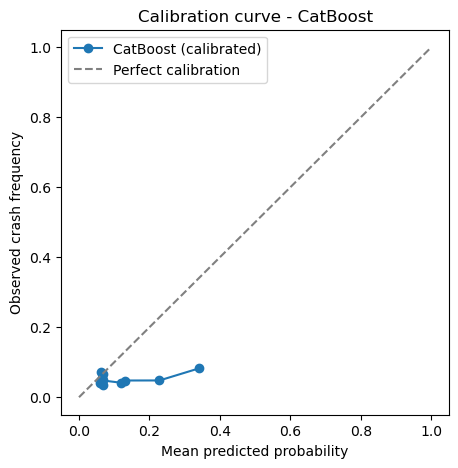

Brier score (CatBoost, out-of-fold): 0.06238230795735628


In [18]:
# Sanity check: out-of-fold reliability diagram + Brier score
oof_probs_cb = np.full(len(y), np.nan)
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5, gap=21).split(X):
    m = CalibratedClassifierCV(
        estimator=CatBoostClassifier(**best_params_cb),
        method='sigmoid',
        cv=3
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_probs_cb[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

mask_cb = ~np.isnan(oof_probs_cb)
frac_pos_cb, mean_pred_cb = calibration_curve(y[mask_cb], oof_probs_cb[mask_cb], n_bins=10, strategy='quantile')

plt.figure(figsize=(5, 5))
plt.plot(mean_pred_cb, frac_pos_cb, marker='o', label='CatBoost (calibrated)')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed crash frequency')
plt.legend()
plt.title('Calibration curve - CatBoost')
plt.show()

print('Brier score (CatBoost, out-of-fold):', brier_score_loss(y[mask_cb], oof_probs_cb[mask_cb]))


## 7. LightGBM — hyperparameter tuning (Optuna)

In [19]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True), # L2 regularization
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255), # Controls tree complexity
        'is_unbalance': True, # Crucial for the minority 'crash' class
        'random_seed': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    tscv = TimeSeriesSplit(n_splits=3, gap=21)
    scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=callbacks
        )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("Starting Optuna Optimization (LightGBM)...")
study_lgb = optuna.create_study(direction='maximize', study_name='lgbm_crash_tuning')
study_lgb.optimize(objective_lgb, n_trials=100)

best_params_lgb = study_lgb.best_params
best_params_lgb['is_unbalance'] = True
best_params_lgb['random_seed'] = 42
best_params_lgb['verbose'] = -1
best_params_lgb['n_jobs'] = -1

print(f"\nBest ROC-AUC (LightGBM): {study_lgb.best_value:.4f}")
print(f"Best Hyperparameters (LightGBM): {best_params_lgb}")


[I 2026-06-19 21:09:22,917] A new study created in memory with name: lgbm_crash_tuning


Starting Optuna Optimization (LightGBM)...


[I 2026-06-19 21:09:23,782] Trial 0 finished with value: 0.6723394563119394 and parameters: {'n_estimators': 745, 'max_depth': 9, 'learning_rate': 0.20925196701292265, 'reg_lambda': 3.2898892332623015, 'bagging_fraction': 0.6305915369135181, 'bagging_freq': 6, 'num_leaves': 155}. Best is trial 0 with value: 0.6723394563119394.
[I 2026-06-19 21:09:24,860] Trial 1 finished with value: 0.6504130625132749 and parameters: {'n_estimators': 999, 'max_depth': 7, 'learning_rate': 0.04395628513688818, 'reg_lambda': 4.285921046664533, 'bagging_fraction': 0.8269978931671238, 'bagging_freq': 5, 'num_leaves': 51}. Best is trial 0 with value: 0.6723394563119394.
[I 2026-06-19 21:09:26,219] Trial 2 finished with value: 0.5715380270438495 and parameters: {'n_estimators': 535, 'max_depth': 9, 'learning_rate': 0.12738749769308486, 'reg_lambda': 0.24915167069246344, 'bagging_fraction': 0.9158051733559631, 'bagging_freq': 2, 'num_leaves': 126}. Best is trial 0 with value: 0.6723394563119394.
[I 2026-06-19 


Best ROC-AUC (LightGBM): 0.7135
Best Hyperparameters (LightGBM): {'n_estimators': 922, 'max_depth': 4, 'learning_rate': 0.2006367115709413, 'reg_lambda': 1.6587762315219337, 'bagging_fraction': 0.7115397396796371, 'bagging_freq': 6, 'num_leaves': 179, 'is_unbalance': True, 'random_seed': 42, 'verbose': -1, 'n_jobs': -1}


## 8. LightGBM — calibration

Same fix as CatBoost: `is_unbalance=True` distorts `predict_proba` away from a true probability, in a way specific to LightGBM's internals. Calibrating with the same method puts it on the same scale as the others.

In [20]:
calibrated_model_lgb = CalibratedClassifierCV(
    estimator=lgb.LGBMClassifier(**best_params_lgb),
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5, gap=21)
)
calibrated_model_lgb.fit(X, y)


,estimator,"LGBMClassifie...7, verbose=-1)"
,method,'sigmoid'
,cv,TimeSeriesSpl...est_size=None)
,n_jobs,None
,ensemble,'auto'
,boosting_type,'gbdt'
,num_leaves,179
,max_depth,4
,learning_rate,0.2006367115709413
,n_estimators,922
,subsample_for_bin,200000


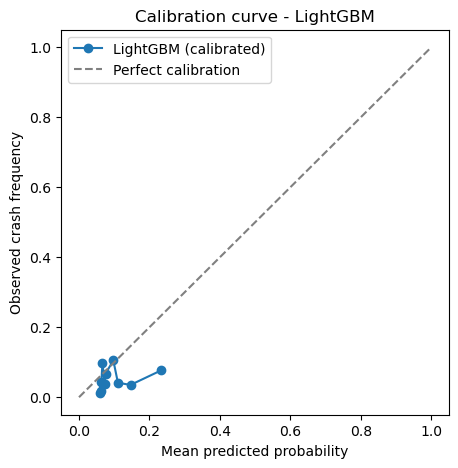

Brier score (LightGBM, out-of-fold): 0.055381530729086255


In [21]:
# Sanity check: out-of-fold reliability diagram + Brier score
oof_probs_lgb = np.full(len(y), np.nan)
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5, gap=21).split(X):
    m = CalibratedClassifierCV(
        estimator=lgb.LGBMClassifier(**best_params_lgb),
        method='sigmoid',
        cv=3
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_probs_lgb[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

mask_lgb = ~np.isnan(oof_probs_lgb)
frac_pos_lgb, mean_pred_lgb = calibration_curve(y[mask_lgb], oof_probs_lgb[mask_lgb], n_bins=10, strategy='quantile')

plt.figure(figsize=(5, 5))
plt.plot(mean_pred_lgb, frac_pos_lgb, marker='o', label='LightGBM (calibrated)')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed crash frequency')
plt.legend()
plt.title('Calibration curve - LightGBM')
plt.show()

print('Brier score (LightGBM, out-of-fold):', brier_score_loss(y[mask_lgb], oof_probs_lgb[mask_lgb]))


## 9. XGBoost — hyperparameter tuning (Optuna)

In [22]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # XGBoost's equivalent of CatBoost's auto_class_weights / LightGBM's
        # is_unbalance: upweight the minority class via scale_pos_weight.
        'scale_pos_weight': scale_pos_weight_value,
        'eval_metric': 'auc',
        'early_stopping_rounds': 50,
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }

    tscv = TimeSeriesSplit(n_splits=3, gap=21)
    scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("Starting Optuna Optimization (XGBoost)...")
study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_crash_tuning')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb['scale_pos_weight'] = scale_pos_weight_value
best_params_xgb['random_state'] = 42
best_params_xgb['verbosity'] = 0
best_params_xgb['n_jobs'] = -1
# Calibration re-fits this estimator without an eval_set, so drop the
# early-stopping params (they require eval_set to do anything).
best_params_xgb.pop('eval_metric', None)
best_params_xgb.pop('early_stopping_rounds', None)

print(f"\nBest ROC-AUC (XGBoost): {study_xgb.best_value:.4f}")
print(f"Best Hyperparameters (XGBoost): {best_params_xgb}")


[I 2026-06-19 21:11:59,223] A new study created in memory with name: xgboost_crash_tuning


Starting Optuna Optimization (XGBoost)...


[I 2026-06-19 21:12:01,950] Trial 0 finished with value: 0.6818083460271525 and parameters: {'n_estimators': 956, 'max_depth': 9, 'learning_rate': 0.011231355599408523, 'reg_lambda': 0.3690601649910861, 'subsample': 0.7543783373624587, 'colsample_bytree': 0.5246933221133796, 'min_child_weight': 9}. Best is trial 0 with value: 0.6818083460271525.
[I 2026-06-19 21:12:04,204] Trial 1 finished with value: 0.7128673388905681 and parameters: {'n_estimators': 922, 'max_depth': 3, 'learning_rate': 0.01672659852056564, 'reg_lambda': 0.6442865638698004, 'subsample': 0.989114364762152, 'colsample_bytree': 0.5798420010328811, 'min_child_weight': 3}. Best is trial 1 with value: 0.7128673388905681.
[I 2026-06-19 21:12:08,083] Trial 2 finished with value: 0.6715625628491911 and parameters: {'n_estimators': 822, 'max_depth': 10, 'learning_rate': 0.011673683554681185, 'reg_lambda': 0.4861474889242364, 'subsample': 0.779151048532299, 'colsample_bytree': 0.7407625061032646, 'min_child_weight': 6}. Best i


Best ROC-AUC (XGBoost): 0.7575
Best Hyperparameters (XGBoost): {'n_estimators': 763, 'max_depth': 3, 'learning_rate': 0.010012856552698592, 'reg_lambda': 0.10685862435027241, 'subsample': 0.7845462237838345, 'colsample_bytree': 0.6983415964281822, 'min_child_weight': 10, 'scale_pos_weight': np.float64(12.264084507042254), 'random_state': 42, 'verbosity': 0, 'n_jobs': -1}


## 10. XGBoost — calibration

`scale_pos_weight` is XGBoost's version of the same trick — it scales up the loss contribution of the minority class. Same distortion, same fix: calibrate post-hoc so the output is a real probability on the same scale as the other models.

In [23]:
calibrated_model_xgb = CalibratedClassifierCV(
    estimator=xgb.XGBClassifier(**best_params_xgb),
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5, gap=21)
)
calibrated_model_xgb.fit(X, y)


,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,TimeSeriesSpl...est_size=None)
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


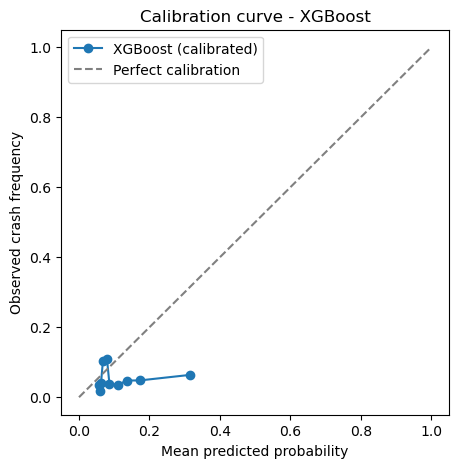

Brier score (XGBoost, out-of-fold): 0.0604247460861702


In [24]:
# Sanity check: out-of-fold reliability diagram + Brier score
oof_probs_xgb = np.full(len(y), np.nan)
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5, gap=21).split(X):
    m = CalibratedClassifierCV(
        estimator=xgb.XGBClassifier(**best_params_xgb),
        method='sigmoid',
        cv=3
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_probs_xgb[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

mask_xgb = ~np.isnan(oof_probs_xgb)
frac_pos_xgb, mean_pred_xgb = calibration_curve(y[mask_xgb], oof_probs_xgb[mask_xgb], n_bins=10, strategy='quantile')

plt.figure(figsize=(5, 5))
plt.plot(mean_pred_xgb, frac_pos_xgb, marker='o', label='XGBoost (calibrated)')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed crash frequency')
plt.legend()
plt.title('Calibration curve - XGBoost')
plt.show()

print('Brier score (XGBoost, out-of-fold):', brier_score_loss(y[mask_xgb], oof_probs_xgb[mask_xgb]))


## 11. Random Forest — hyperparameter tuning (Optuna)

In [25]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        # Random Forest's equivalent of the other models' imbalance handling:
        # reweight samples inversely proportional to class frequency.
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    # Random Forest has no native eval_set/early stopping, but we still use
    # the same TimeSeriesSplit(gap=21) so the comparison across models is
    # apples-to-apples.
    tscv = TimeSeriesSplit(n_splits=3, gap=21)
    scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)

print("Starting Optuna Optimization (Random Forest)...")
study_rf = optuna.create_study(direction='maximize', study_name='rf_crash_tuning')
study_rf.optimize(objective_rf, n_trials=100)

best_params_rf = study_rf.best_params
best_params_rf['class_weight'] = 'balanced'
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

print(f"\nBest ROC-AUC (Random Forest): {study_rf.best_value:.4f}")
print(f"Best Hyperparameters (Random Forest): {best_params_rf}")


[I 2026-06-19 21:14:55,664] A new study created in memory with name: rf_crash_tuning


Starting Optuna Optimization (Random Forest)...


[I 2026-06-19 21:15:20,432] Trial 0 finished with value: 0.645969715084586 and parameters: {'n_estimators': 799, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 15, 'max_features': 0.8758036334949544}. Best is trial 0 with value: 0.645969715084586.
[I 2026-06-19 21:15:48,260] Trial 1 finished with value: 0.607881885718979 and parameters: {'n_estimators': 817, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 0.7845172165727035}. Best is trial 0 with value: 0.645969715084586.
[I 2026-06-19 21:16:08,946] Trial 2 finished with value: 0.6493378876679343 and parameters: {'n_estimators': 887, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 0.4665070876736671}. Best is trial 2 with value: 0.6493378876679343.
[I 2026-06-19 21:16:22,192] Trial 3 finished with value: 0.6555622648207317 and parameters: {'n_estimators': 464, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 0.771018548727524


Best ROC-AUC (Random Forest): 0.6664
Best Hyperparameters (Random Forest): {'n_estimators': 982, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 17, 'max_features': 0.8525987521149532, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


## 12. Random Forest — calibration

`class_weight='balanced'` is sklearn's version of the same imbalance trick — it reweights samples inversely to class frequency. Random Forest's `predict_proba` is also notoriously poorly calibrated even without class weighting (it's an average of unanchored tree-leaf fractions), so calibration matters here at least as much as for the boosted trees.

In [26]:
calibrated_model_rf = CalibratedClassifierCV(
    estimator=RandomForestClassifier(**best_params_rf),
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5, gap=21)
)
calibrated_model_rf.fit(X, y)


,estimator,RandomForestC...ndom_state=42)
,method,'sigmoid'
,cv,TimeSeriesSpl...est_size=None)
,n_jobs,None
,ensemble,'auto'
,n_estimators,982
,criterion,'gini'
,max_depth,5
,min_samples_split,11
,min_samples_leaf,17
,min_weight_fraction_leaf,0.0


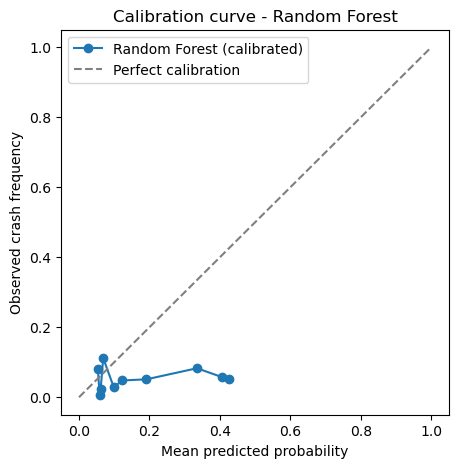

Brier score (Random Forest, out-of-fold): 0.08674350509724357


In [27]:
# Sanity check: out-of-fold reliability diagram + Brier score
oof_probs_rf = np.full(len(y), np.nan)
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5, gap=21).split(X):
    m = CalibratedClassifierCV(
        estimator=RandomForestClassifier(**best_params_rf),
        method='sigmoid',
        cv=3
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_probs_rf[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

mask_rf = ~np.isnan(oof_probs_rf)
frac_pos_rf, mean_pred_rf = calibration_curve(y[mask_rf], oof_probs_rf[mask_rf], n_bins=10, strategy='quantile')

plt.figure(figsize=(5, 5))
plt.plot(mean_pred_rf, frac_pos_rf, marker='o', label='Random Forest (calibrated)')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed crash frequency')
plt.legend()
plt.title('Calibration curve - Random Forest')
plt.show()

print('Brier score (Random Forest, out-of-fold):', brier_score_loss(y[mask_rf], oof_probs_rf[mask_rf]))


## 13. All four models, on the same scale

In [28]:
crash_probs_cb = calibrated_model_cb.predict_proba(pred_data)[:, 1] * 100
crash_probs_lgb = calibrated_model_lgb.predict_proba(pred_data)[:, 1] * 100
crash_probs_xgb = calibrated_model_xgb.predict_proba(pred_data)[:, 1] * 100
crash_probs_rf = calibrated_model_rf.predict_proba(pred_data)[:, 1] * 100

crash_probs_cb_ema = pd.Series(crash_probs_cb).ewm(span=5).mean()
crash_probs_lgb_ema = pd.Series(crash_probs_lgb).ewm(span=5).mean()
crash_probs_xgb_ema = pd.Series(crash_probs_xgb).ewm(span=5).mean()
crash_probs_rf_ema = pd.Series(crash_probs_rf).ewm(span=5).mean()

comparison = pd.DataFrame({
    'date': pred_data.index,
    'CatBoost_%': crash_probs_cb,
    'CatBoost_ema_%': crash_probs_cb_ema.values,
    'LightGBM_%': crash_probs_lgb,
    'LightGBM_ema_%': crash_probs_lgb_ema.values,
    'XGBoost_%': crash_probs_xgb,
    'XGBoost_ema_%': crash_probs_xgb_ema.values,
    'RandomForest_%': crash_probs_rf,
    'RandomForest_ema_%': crash_probs_rf_ema.values,
})
comparison['Blended_ema_%'] = comparison[
    ['CatBoost_ema_%', 'LightGBM_ema_%', 'XGBoost_ema_%', 'RandomForest_ema_%']
].mean(axis=1)
comparison


,date,CatBoost_%,CatBoost_ema_%,LightGBM_%,LightGBM_ema_%,XGBoost_%,XGBoost_ema_%,RandomForest_%,RandomForest_ema_%,Blended_ema_%
0,2026-05-19,5.365005,5.365005,5.441607,5.441607,8.455845,8.455845,9.730340,9.730340,7.248199
1,2026-05-20,5.221754,5.279054,4.974466,5.161322,7.892069,8.117579,9.058101,9.326997,6.971238
2,2026-05-21,5.322030,5.299411,4.884856,5.030365,7.632710,7.887904,9.007149,9.175490,6.848293
3,2026-05-22,5.253171,5.280204,4.589024,4.847039,7.488870,7.722152,9.027113,9.113856,6.740813
4,2026-05-25,5.811462,5.484147,4.435515,4.689060,12.727045,9.643462,10.421650,9.615900,7.358142
5,2026-05-26,5.350338,5.435251,4.410946,4.587434,7.205611,8.752638,8.607314,9.247349,7.005668
6,2026-05-27,5.353237,5.406213,4.526636,4.565908,7.275587,8.229680,8.940725,9.138787,6.835147
7,2026-05-29,5.186024,5.329837,4.691851,4.609593,6.146989,7.507262,9.392736,9.226874,6.668392
8,2026-06-01,5.162654,5.272621,5.030616,4.753682,6.011091,6.995219,9.376933,9.278229,6.574938
9,2026-06-02,5.160401,5.234554,5.033364,4.848555,5.986681,6.653107,9.162997,9.239141,6.493839


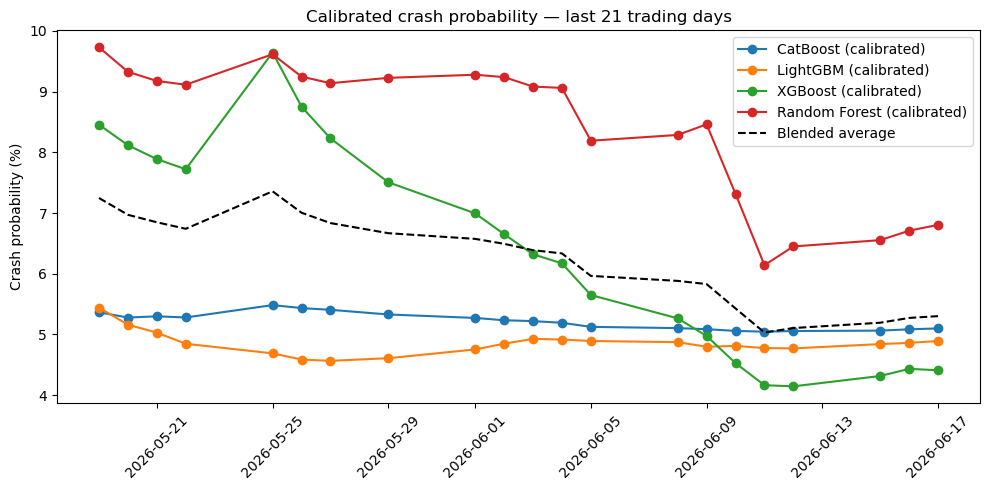

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(comparison['date'], comparison['CatBoost_ema_%'], marker='o', label='CatBoost (calibrated)')
plt.plot(comparison['date'], comparison['LightGBM_ema_%'], marker='o', label='LightGBM (calibrated)')
plt.plot(comparison['date'], comparison['XGBoost_ema_%'], marker='o', label='XGBoost (calibrated)')
plt.plot(comparison['date'], comparison['RandomForest_ema_%'], marker='o', label='Random Forest (calibrated)')
plt.plot(comparison['date'], comparison['Blended_ema_%'], linestyle='--', color='black', label='Blended average')
plt.ylabel('Crash probability (%)')
plt.title('Calibrated crash probability — last 21 trading days')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [30]:
# Brier scores side by side -- lower is better, and now directly comparable
# because every model went through the same calibration procedure.
pd.DataFrame({
    'model': ['CatBoost', 'LightGBM', 'XGBoost', 'Random Forest'],
    'brier_score': [
        brier_score_loss(y[mask_cb], oof_probs_cb[mask_cb]),
        brier_score_loss(y[mask_lgb], oof_probs_lgb[mask_lgb]),
        brier_score_loss(y[mask_xgb], oof_probs_xgb[mask_xgb]),
        brier_score_loss(y[mask_rf], oof_probs_rf[mask_rf]),
    ]
}).sort_values('brier_score')


,model,brier_score
1,LightGBM,0.055382
2,XGBoost,0.060425
0,CatBoost,0.062382
3,Random Forest,0.086744


In [31]:
comparison.iloc[-1:]

,date,CatBoost_%,CatBoost_ema_%,LightGBM_%,LightGBM_ema_%,XGBoost_%,XGBoost_ema_%,RandomForest_%,RandomForest_ema_%,Blended_ema_%
20,2026-06-17,5.131235,5.100427,4.95408,4.892669,4.364684,4.410958,6.996637,6.805351,5.302351
